### Das Primäre Ziel dieses Notebooks war die Untersuchung eines möglichen Zusammenhangs zwischen dem wirtschaftlichen Wohlstand eines Landes, gemessen am BIP pro Kopf und der Mortalität durch übertragbare Krankheiten. 

In [1]:
#Wichtige Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re




Es wurde die Datei country_lookup.csv geladen und nicht die finale base_data104_with_lookup.csv, da in der country_lookup-Datei die Todesursachen noch nicht gemappt sind. Dadurch lassen sich die Cause-Codes (ICD-10) mit einem einfacheren Verfahren besser zuordnen.

In [2]:
df = pd.read_csv("Data_Files/country_lookup.csv")
#Da wir nur die Spalten Country, Year, Cause und Deaths1 brauchen, filtern wir den DataFrame entsprechend
df = df[["Country", "Year", "Cause", "Sex", "Deaths1"]]
#Kurzer Check der Dimensionen des DataFrames
print("Reihen:", len(df))
print("Spalten:", df.columns.tolist())


Reihen: 4710902
Spalten: ['Country', 'Year', 'Cause', 'Sex', 'Deaths1']


### Hier wollen wir herausfinden, ob Todesursachen ohne Todesfälle mit 0 oder einem anderen Wert angegeben sind und wie viele Einträge tatsächlich keine Todesfälle enthalten

In [3]:
#Konvertiert die Spalte "Deaths1" in numerische Werte, wobei nicht konvertierbare Werte in NaN umgewandelt werden
df["Deaths1"] = pd.to_numeric(df["Deaths1"], errors="coerce")

#Überprüft auf NaN-Werte und Zeros in der Spalte "Deaths1"
num_missing = df["Deaths1"].isna().sum()
num_zeros = (df["Deaths1"] == 0).sum()

print(f"{num_missing} NaN werte in 'Deaths at all ages'")
print(f"{num_zeros} Null werte in 'Deaths at all ages'")


0 NaN werte in 'Deaths at all ages'
7602 Null werte in 'Deaths at all ages'


### Im nächsten Schritt führen wir eine Analyse der allgemeinen Datenqualität unseres Datensatzes durch, um unter anderem zu bestimmen, welche Länder ausreichend Daten enthalten und sich für einen Vergleich eignen.

Wieviele Länder sind in unserem Datensatz?

In [4]:
df["Country"].nunique()

124

Welche Länder sind im Datensatz enthalten?

In [5]:
sorted(df["Country"].unique())

['Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Bahamas',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Bermuda',
 'Bolivia',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Canada',
 'Cayman Islands',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Estonia',
 'Fiji',
 'France',
 'French Guiana',
 'Georgia',
 'Germany',
 'Greece',
 'Grenada',
 'Guadeloupe',
 'Guatemala',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hong Kong SAR',
 'Hungary',
 'Iceland',
 'Iran (Islamic Republic of)',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kiribati',
 'Kuwait',
 'Kyrgyzstan',
 'Latvia',
 'Lebanon',
 'Lithuania',
 'Luxembourg',
 'Maldives',
 'Malta',
 'Martinique',
 'Mauritius',
 'Mayotte',
 'Mexico',
 'Micronesia (Federated States of)',
 'Mongolia',
 'Mont

Wieviele Einträge pro Land sind im Datensatz enthalten

In [6]:
df["Country"].value_counts()


Country
Brazil                       307521
United States of America     160718
Mexico                       155631
Japan                        139281
Germany                      135943
                              ...  
Qatar                           710
Montenegro                      624
Kiribati                        469
Solomon Islands                 463
Saint Pierre and Miquelon       209
Name: count, Length: 124, dtype: int64

Wie viele Jahre sind pro Land im Datensatz enthalten? (coverage)

In [7]:
coverage = df.groupby("Country")["Year"].nunique().reset_index(name="Years_Reported").sort_values("Years_Reported", ascending=False)
print(coverage)


                        Country  Years_Reported
27               Czech Republic              30
28                      Denmark              29
109                 Switzerland              28
47                      Hungary              28
65                        Malta              27
..                          ...             ...
14                     Botswana               1
49   Iran (Islamic Republic of)               1
9                       Belarus               1
100                      Serbia               1
89                        Qatar               1

[124 rows x 2 columns]


In diesem Abschnitt wurde der Datensatz bereinigt und hinsichtlich der Datenverfügbarkeit analysiert. Dabei wurden ungültige Länder- und Jahresangaben entfernt sowie unterschiedliche Ländernamen vereinheitlicht, um eine konsistente Zusammenfassung der Daten zu ermöglichen.

Anschliessend wurde gezählt, wie viele Einträge pro Land und Jahr vorhanden sind, und eine Länder-Jahres-Übersicht erstellt, wobei fehlende Werte als keine vorhandenen Daten interpretiert wurden. Für die Jahre 2010 bis 2020 wurden nur Länder mit mindestens 2.000 Einträgen berücksichtigt. Die Ergebnisse wurden abschliessend in einer Heatmap visualisiert.

Überseegebiete wurden nur dann aggregiert, wenn sie integrale administrative Einheiten des jeweiligen Mutterstaates darstellen und in internationalen Gesundheitsstatistiken üblicherweise gemeinsam berichtet werden. Andere Gebiete und kleine Staaten wurden als eigenständige Einheiten beibehalten, um die epidemiologische Vergleichbarkeit zu gewährleisten.

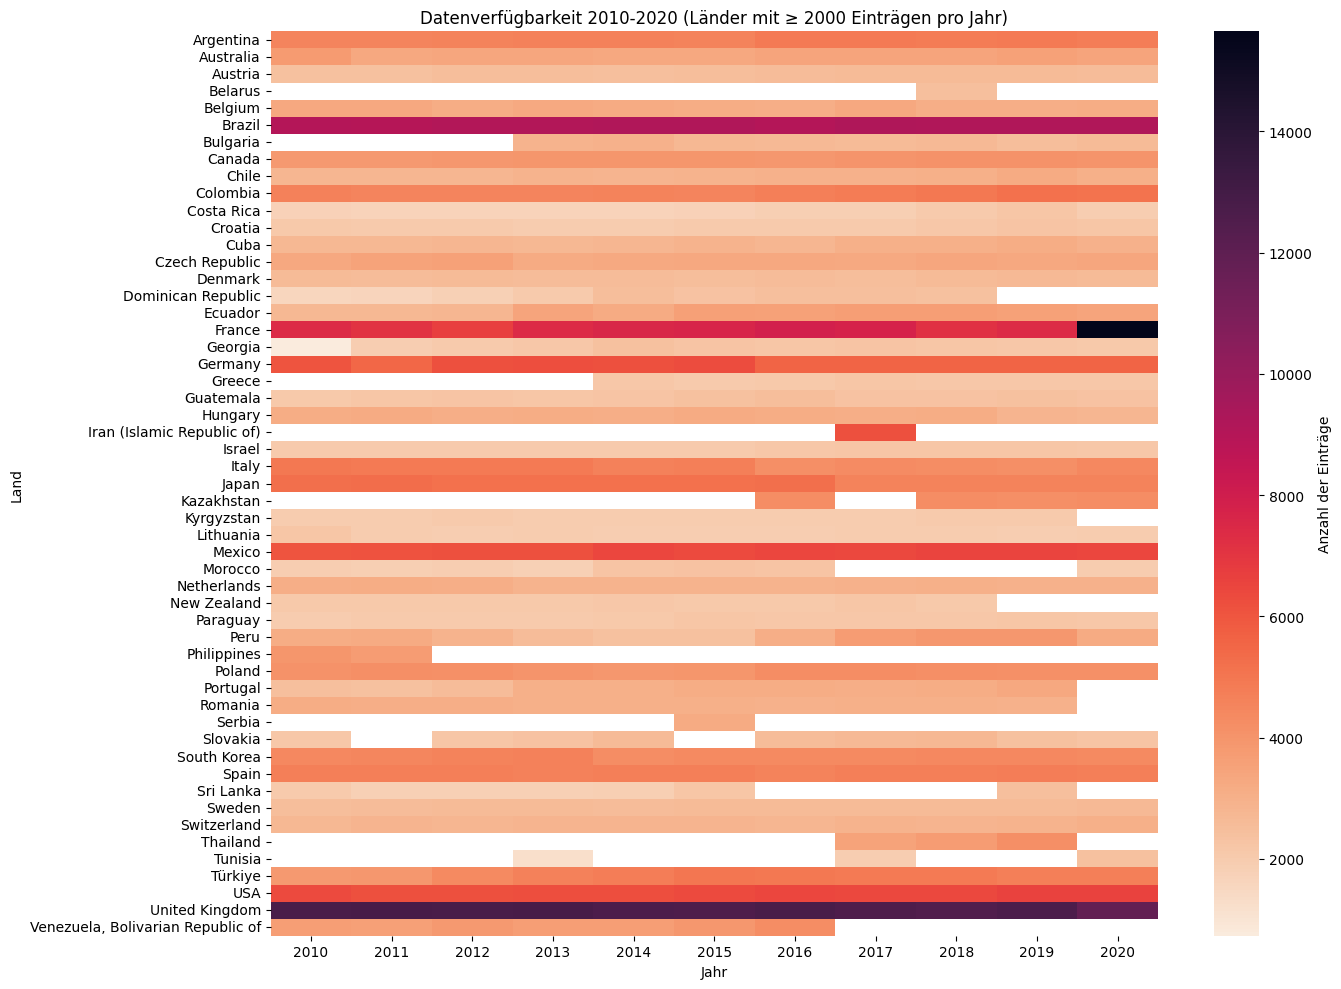

In [8]:
#Stellt sicher, dass die Spalte "Year" numerisch ist und entfernt Zeilen mit ungültigen oder fehlenden Werten in den Spalten "Country" oder "Year"
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Country", "Year"])

#Einheitliche Länderkodierung
country_map = {
    "United States of America": "USA",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States",}
df["Country_clean"] = df["Country"].replace(country_map)

#Zählt die Anzahl der Einträge pro Land und Jahr
count_df = (df.groupby(["Country_clean", "Year"]).size().reset_index(name="Entries"))

#Bereitet die Heatmap-Daten vor
all_countries = sorted(df["Country_clean"].unique())
all_years = sorted(df["Year"].unique())

heatmap_data = (count_df.pivot(index="Country_clean", columns="Year", values="Entries").reindex(index=all_countries, columns=all_years))

#Filtert die Jahre von 2010 bis 2020
years_filter = [y for y in heatmap_data.columns if 2010 <= y <= 2020]
filtered_years_data = heatmap_data[years_filter]

#Es werden nur Länder mit mindestens 2000 Einträgen pro Jahr berücksichtigt
mindestens = 2000
filtered_heatmap_data = filtered_years_data[filtered_years_data.max(axis=1) >= mindestens]

#Plottet die Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(filtered_heatmap_data, cmap="rocket_r", cbar_kws={"label": "Anzahl der Einträge"},linewidths=0.0)
plt.title("Datenverfügbarkeit 2010-2020 (Länder mit ≥ 2000 Einträgen pro Jahr)")
plt.xlabel("Jahr")
plt.ylabel("Land")
plt.tight_layout()
plt.show()


Mithilfe der Heatmap lässt sich grob erkennen, dass die Jahre 2010 bis 2020 eine ähnliche Anzahl an Einträgen aufweisen. Aus diesem Grund wurde im Notebook „Übersicht“ zusätzlich ein Säulendiagramm erstellt, um ein Jahr mit der höchsten Datenverfügbarkeit zu identifizieren. Auf dieser Grundlage wurde schliesslich das Jahr 2017 für die weitere Analyse ausgewählt.

Nun schauen wir uns an, wieviele Einträge die Länder für das Jahr 2017 haben.

In [9]:
df_2017 = df[df["Year"] == 2017]
counts = df_2017["Country"].value_counts()
print(counts)


Country
Brazil                        9230
Mexico                        6441
United States of America      6415
Iran (Islamic Republic of)    6205
Germany                       5589
                              ... 
Rodrigues                      109
British Virgin Islands          84
Turks and Caicos Islands        75
Anguilla                        67
Montserrat                      30
Name: count, Length: 93, dtype: int64


Der Datensatz wird weiter bereinigt, indem wir zunächst alle im Datensatz enthaltenen Länder identifizieren. Anschliessend wird der Datensatz auf das zuvor ausgewählte Jahr 2017 gefiltert. Dabei wird überprüft, wie viele Einträge und wie viele unterschiedliche Länder für dieses Jahr im Datensatz vorhanden sind.

In [10]:
#Liste aller Länder im Datensatz
all_countries = sorted(df["Country_clean"].dropna().unique())
print(f"Es wurden {len(all_countries)} Länder im Datensatz gefunden.")

#Filtert den DataFrame für das Jahr 2017
df_2017 = df[df["Year"] == 2017].copy()

print(f"Nach dem Filtrieren sind {len(df_2017):,} Reihen für das Jahr 2017 vorhanden.")
print(f"Es sind {df_2017['Country_clean'].nunique()} Länder im Jahr 2017 vertreten.")




Es wurden 114 Länder im Datensatz gefunden.
Nach dem Filtrieren sind 208,555 Reihen für das Jahr 2017 vorhanden.
Es sind 83 Länder im Jahr 2017 vertreten.


Wir bereiten die Spalte „Cause“ auf, indem wir alle Werte als String speichern, Leerzeichen entfernen und die Codes in Grossbuchstaben umwandeln. Anschliessend entfernen wir aggregierte ICD-Codes, also Einträge, die keine spezifischen Diagnosen darstellen (z. B. dreibuchstabige Sammelcodes wie „AAA“). Dadurch bleiben nur detaillierte ICD-10-Codes für die weitere Analyse übrig.

In [11]:
df_2017["Cause"] = df_2017["Cause"].astype(str).str.strip().str.upper()

#Entfernt Einträge mit Ursachen, die nur aus drei Großbuchstaben bestehen
df_2017_backup = df_2017[(~df_2017["Cause"].str.fullmatch(r"[A-Z]{3}"))].copy()
df_correct_icd = df_2017[(~df_2017["Cause"].str.fullmatch(r"[A-Z]{3}"))].copy()


In diesem Schritt werden die ICD-10-Codes anhand ihres Anfangsbuchstabens in übergeordnete Krankheitskategorien eingeteilt. Dabei werden übertragbare Krankheiten, nicht-übertragbare Krankheiten sowie Verletzungen und externe Ursachen unterschieden. Die zugehörige Kategorie wird anschliessend für jede Todesursache in einer neuen Spalte gespeichert und für die weitere Analyse verwendet.

Quelle: https://icd.who.int/browse10/2019/en

In [12]:
def categorize_icd10(code):
    
    c = str(code)
    first = c[0]

    if first in ["A", "B"]:
        return "Communicable Diseases"

    if first in list("CDEFGHIJKLMN"):
        return "Noncommunicable Diseases"

    if first in list("STVWXY"):
        return "Injuries & External Causes"

    return "Other/Unclassified"

df_correct_icd["Category"] = df_correct_icd["Cause"].apply(categorize_icd10)

In diesem Schritt werden die Todesfälle pro Land, Jahr und Kategorie (z. B. übertragbar / nicht-übertragbar / Verletzungen) aggregiert, indem die Spalte Deaths1 aufsummiert wird. Anschliessend wird für jede Kategorie der prozentuale Anteil an allen Todesfällen eines Landes in einem bestimmten Jahr berechnet und in der Spalte "Percent" gespeichert

In [13]:
df_with_icd = (df_correct_icd.groupby(["Country_clean", "Year", "Category"], as_index=False)["Deaths1"].sum())

df_with_icd["Percent"] = (df_with_icd["Deaths1"] /df_with_icd.groupby(["Country_clean", "Year"])["Deaths1"].transform("sum") * 100)


Der aggregierte Datensatz wird nun für das Jahr 2017 gefiltert und exemplarisch für Schweiz, Kirgisistan und Brasilien ausgegeben. Die Ergebnisse werden nach dem prozentualen Anteil sortiert, um zu sehen, welche Kategorie in jedem Land im Jahr 2017 den grössten Anteil an Todesfällen ausmacht

In [14]:
swiss_2017 = (
    df_with_icd[(df_with_icd["Country_clean"] == "Switzerland") & (df_with_icd["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(swiss_2017)

kirgistan_2017 = (
    df_with_icd[(df_with_icd["Country_clean"] == "Kyrgyzstan") & (df_with_icd["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(kirgistan_2017)

brazil_2017 = (
    df_with_icd[(df_with_icd["Country_clean"] == "Brazil") & (df_with_icd["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(brazil_2017)

    Country_clean  Year                    Category  Deaths1    Percent
292   Switzerland  2017    Noncommunicable Diseases    59166  88.345702
291   Switzerland  2017  Injuries & External Causes     3734   5.575548
293   Switzerland  2017          Other/Unclassified     3263   4.872258
290   Switzerland  2017       Communicable Diseases      808   1.206492
    Country_clean  Year                    Category  Deaths1    Percent
174    Kyrgyzstan  2017    Noncommunicable Diseases    26460  79.780498
175    Kyrgyzstan  2017          Other/Unclassified     3046   9.184104
173    Kyrgyzstan  2017  Injuries & External Causes     2856   8.611228
172    Kyrgyzstan  2017       Communicable Diseases      804   2.424169
   Country_clean  Year                    Category  Deaths1    Percent
38        Brazil  2017    Noncommunicable Diseases   992855  75.636644
37        Brazil  2017  Injuries & External Causes   158777  12.095784
39        Brazil  2017          Other/Unclassified   106158   8.087

Um zwischen Ländern mit höherem und mittlerem Einkommen zu unterscheiden, werden wir die Einkommensklassifikation der Weltbank verwenden. Dort werden die Schweiz, Japan,  Kanada, als High-Income (Bruttonationaleinkommen pro Kopf >$13'935) Länder eingestuft, während Mexico, Brasilien und Kolumbien zu den Upper-Middle-Income (Bruttonationaleinkommen pro Kopf zwischen $4'496 - $13'935) Länder zählen. Kirgistan und Nicaragua gelten als Lower-Middle-Income (Bruttonationaleinkommen pro Kopf zwischen $1'136 - $4'495) Länder. 

Quelle: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519

In diesem Abschnitt werden die ausgewählten Länder für das Jahr 2017 miteinander verglichen. Dazu werden die prozentualen Anteile der Todesursachenkategorien berechnet, in einer Tabelle zusammengefasst und dann in einem gestapelten Balkendiagramm visualisiert.


 Prozentualer Anteil der Tode nach Ursache für das Jahr 2017 

    Country  Communicable Diseases  Injuries & External Causes  Noncommunicable Diseases  Other/Unclassified
Switzerland                   1.21                        5.58                     88.35                4.87
      Japan                   1.85                        5.12                     83.58                9.46
     Canada                   1.54                        6.85                     89.36                2.24
     Mexico                   2.28                       11.43                     81.56                4.73
   Colombia                   2.70                       12.59                     80.20                4.51
     Brazil                   4.18                       12.10                     75.64                8.09
  Nicaragua                   2.74                        9.03                     79.04                9.19
 Kyrgyzstan                   2.42                        8.61  

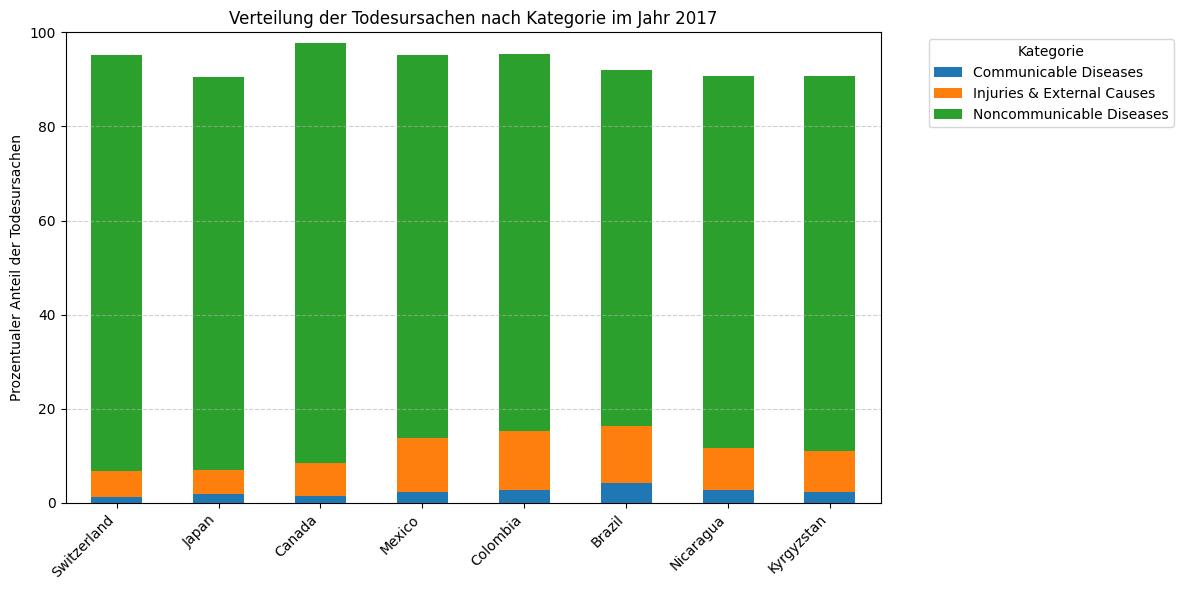

In [15]:

countries_to_compare = ["Switzerland", "Japan", "Canada", "Mexico", "Colombia", "Brazil", "Nicaragua", "Kyrgyzstan"]
#Filtert auf 2017 und Länder der Vergleichsgruppe

df_2017_comp = df_with_icd[(df_with_icd["Year"] == 2017) & (df_with_icd["Country_clean"].isin(countries_to_compare))].copy()

#Pivot-Tabelle erstellen
table_clean = (df_2017_comp.pivot(index="Country_clean", columns="Category", values="Percent").round(2).reset_index().rename(columns={"Country_clean": "Country"}))

#Erstellt eine sortierte Liste der Länder für die Anzeige
country_order = ["Switzerland", "Japan", "Canada", "Mexico", "Colombia", "Brazil", "Nicaragua", "Kyrgyzstan"]
table_clean["Country"] = pd.Categorical(table_clean["Country"], categories=country_order, ordered=True)
table_clean = table_clean.sort_values("Country")

print("\n Prozentualer Anteil der Tode nach Ursache für das Jahr 2017 \n")
print(table_clean.to_string(index=False))

#Definiert die Reihenfolge der Kategorien für die Anzeige
category_order = ["Communicable Diseases","Injuries & External Causes", "Noncommunicable Diseases"]

#Erstellt das gestapelte Balkendiagramm
ax = table_clean.set_index("Country")[category_order].plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Verteilung der Todesursachen nach Kategorie im Jahr 2017")
plt.ylabel("Prozentualer Anteil der Todesursachen")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kategorie", bbox_to_anchor=(1.05, 1))
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Die Abbildung stellt die Anteile der Todesursachenkategorien pro Land im Jahr 2017 getrennt nach Kategorien dar.

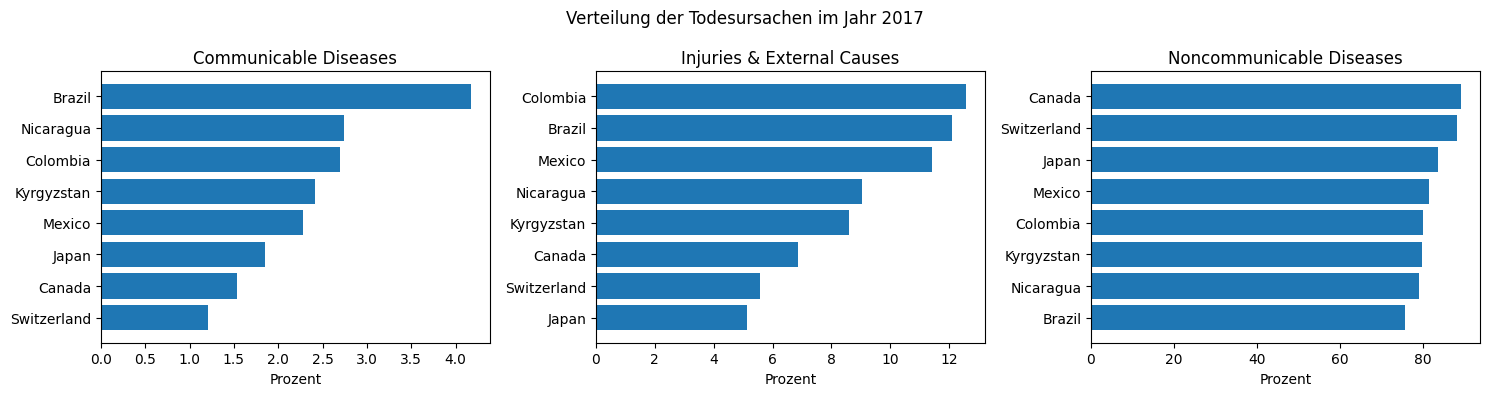

In [16]:
categories = ["Communicable Diseases", "Injuries & External Causes","Noncommunicable Diseases"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cat in zip(axes, categories):
    plot_data = table_clean.sort_values(cat)
    ax.barh(plot_data["Country"], plot_data[cat])
    ax.set_title(cat)
    ax.set_xlabel("Prozent")

plt.suptitle("Verteilung der Todesursachen im Jahr 2017")
plt.tight_layout()
plt.show()


Die Abbildungen verdeutlichen, dass nicht-übertragbare Krankheiten in allen untersuchten Ländern den mit Abstand größten Anteil an den Todesursachen ausmachen. In Ländern mit höherem Einkommen wie der Schweiz, Japan und Kanada ist der Anteil übertragbarer Krankheiten sehr gering, während Verletzungen und externe Ursachen ebenfalls nur einen kleinen Teil ausmachen. In Ländern mit mittlerem und niedrigerem Einkommen, insbesondere in Nicaragua, Kirgisistan, Brasilien und Kolumbien, ist hingegen ein höherer Anteil sowohl übertragbarer Krankheiten als auch von Verletzungen zu beobachten.

Auffällig ist jedoch, dass selbst in Ländern mit niedrigerem bzw. unterem mittlerem Einkommensniveau wie Kirgisistan und Nicaragua der Anteil übertragbarer Krankheiten vergleichsweise gering ausfällt. Dies widerspricht teilweise der Erwartung, dass in diesen Ländern übertragbare Krankheiten einen deutlich höheren Anteil an den Todesursachen haben sollten. Stattdessen dominieren auch hier nicht-übertragbare Krankheiten, was darauf hindeutet, dass sich die Krankheitslast in diesen Ländern bereits stärker in Richtung chronischer Erkrankungen verschoben hat. Darauf gehen wir allerdings am Ende dieses Notebooks nochmal genauer ein.

### Other / Unclassified

In diesem Abschnitt wird die Kategorie „Other / Unclassified“ näher untersucht, um besser zu verstehen, welche Todesursachen in diese Restkategorie fallen. Dazu werden alle ICD-10-Codes analysiert, die im vorherigen Schritt keiner der drei Hauptkategorien zugeordnet werden konnten.

Zur genaueren Einordnung wurden diese Todesursachen anhand ihrer ICD-10-Präfixe weiter unterteilt. Dadurch lässt sich beurteilen, ob die Kategorie „Other / Unclassified“ überwiegend durch schlecht definierte Ursachen, maternale und perinatale Erkrankungen, angeborene Fehlbildungen oder spezielle ICD-Codes geprägt ist. Die Analyse erfolgt auf Länderebene für das Jahr 2017 und liefert Hinweise auf mögliche Unterschiede in der Datenqualität sowie in den Praktiken der Todesursachenkodierung zwischen den Ländern.

In [17]:
def refine_other(code):
    c = str(code).strip().upper()
    if c.startswith("O"):
        return "Maternal causes"
    if c.startswith("P"):
        return "Perinatal conditions"
    if c.startswith("Q"):
        return "Congenital disorders"
    if c.startswith("R"):
        return "Ill-defined and unknown causes"


In diesem Schritt werden die Todesfälle der Kategorie „Other / Unclassified“ für das Jahr 2017 auf Länderebene nach weiterführenden Unterkategorien aggregiert. Für jedes Land wird die Anzahl der Todesfälle pro Unterkategorie aufsummiert und anschliessend der prozentuale Anteil jeder Unterkategorie an allen „Other“-Todesfällen des jeweiligen Landes berechnet. Die Ergebnisse werden nach Ländern und absteigendem prozentualen Anteil sortiert, um die interne Zusammensetzung dieser Restkategorie vergleichbar darzustellen.

In [18]:
df_2017_other = df_2017_backup.copy()
df_2017_other["Other_Subcategory"] = df_2017_other["Cause"].apply(refine_other)

other_summary = (
    df_2017_other
    .dropna(subset=["Other_Subcategory"])   # keep only O/P/Q/R/U
    .groupby(["Country_clean", "Other_Subcategory"], as_index=False)["Deaths1"]
    .sum()
)

other_summary["Percent"] = (
    other_summary["Deaths1"] /
    other_summary.groupby("Country_clean")["Deaths1"].transform("sum") * 100
).round(2)

other_summary = other_summary.sort_values(["Country_clean", "Percent"], ascending=[True, False])

print("\n Detaillierte Aufschlüsselung der 'Other/Unclassified' Todesursachen für das Jahr 2017 \n")
print(other_summary.to_string(index=False))



 Detaillierte Aufschlüsselung der 'Other/Unclassified' Todesursachen für das Jahr 2017 

               Country_clean              Other_Subcategory  Deaths1  Percent
                    Anguilla           Perinatal conditions        3    75.00
                    Anguilla                Maternal causes        1    25.00
         Antigua and Barbuda Ill-defined and unknown causes        9    52.94
         Antigua and Barbuda           Perinatal conditions        5    29.41
         Antigua and Barbuda           Congenital disorders        3    17.65
                   Argentina Ill-defined and unknown causes    20544    77.40
                   Argentina           Perinatal conditions     3388    12.76
                   Argentina           Congenital disorders     2365     8.91
                   Argentina                Maternal causes      246     0.93
                     Armenia Ill-defined and unknown causes      194    34.34
                     Armenia           Perinatal con

Die Abbildung visualisiert die prozentuale Zusammensetzung der „Other / Unclassified“-Todesfälle im Jahr 2017 nach Unterkategorien (O/P/Q/R) für jedes Land. Die 100%-gestapelten, horizontalen Balken ermöglichen einen direkten Vergleich der Verteilung innerhalb der Länder, unabhängig von der absoluten Anzahl an Todesfällen.

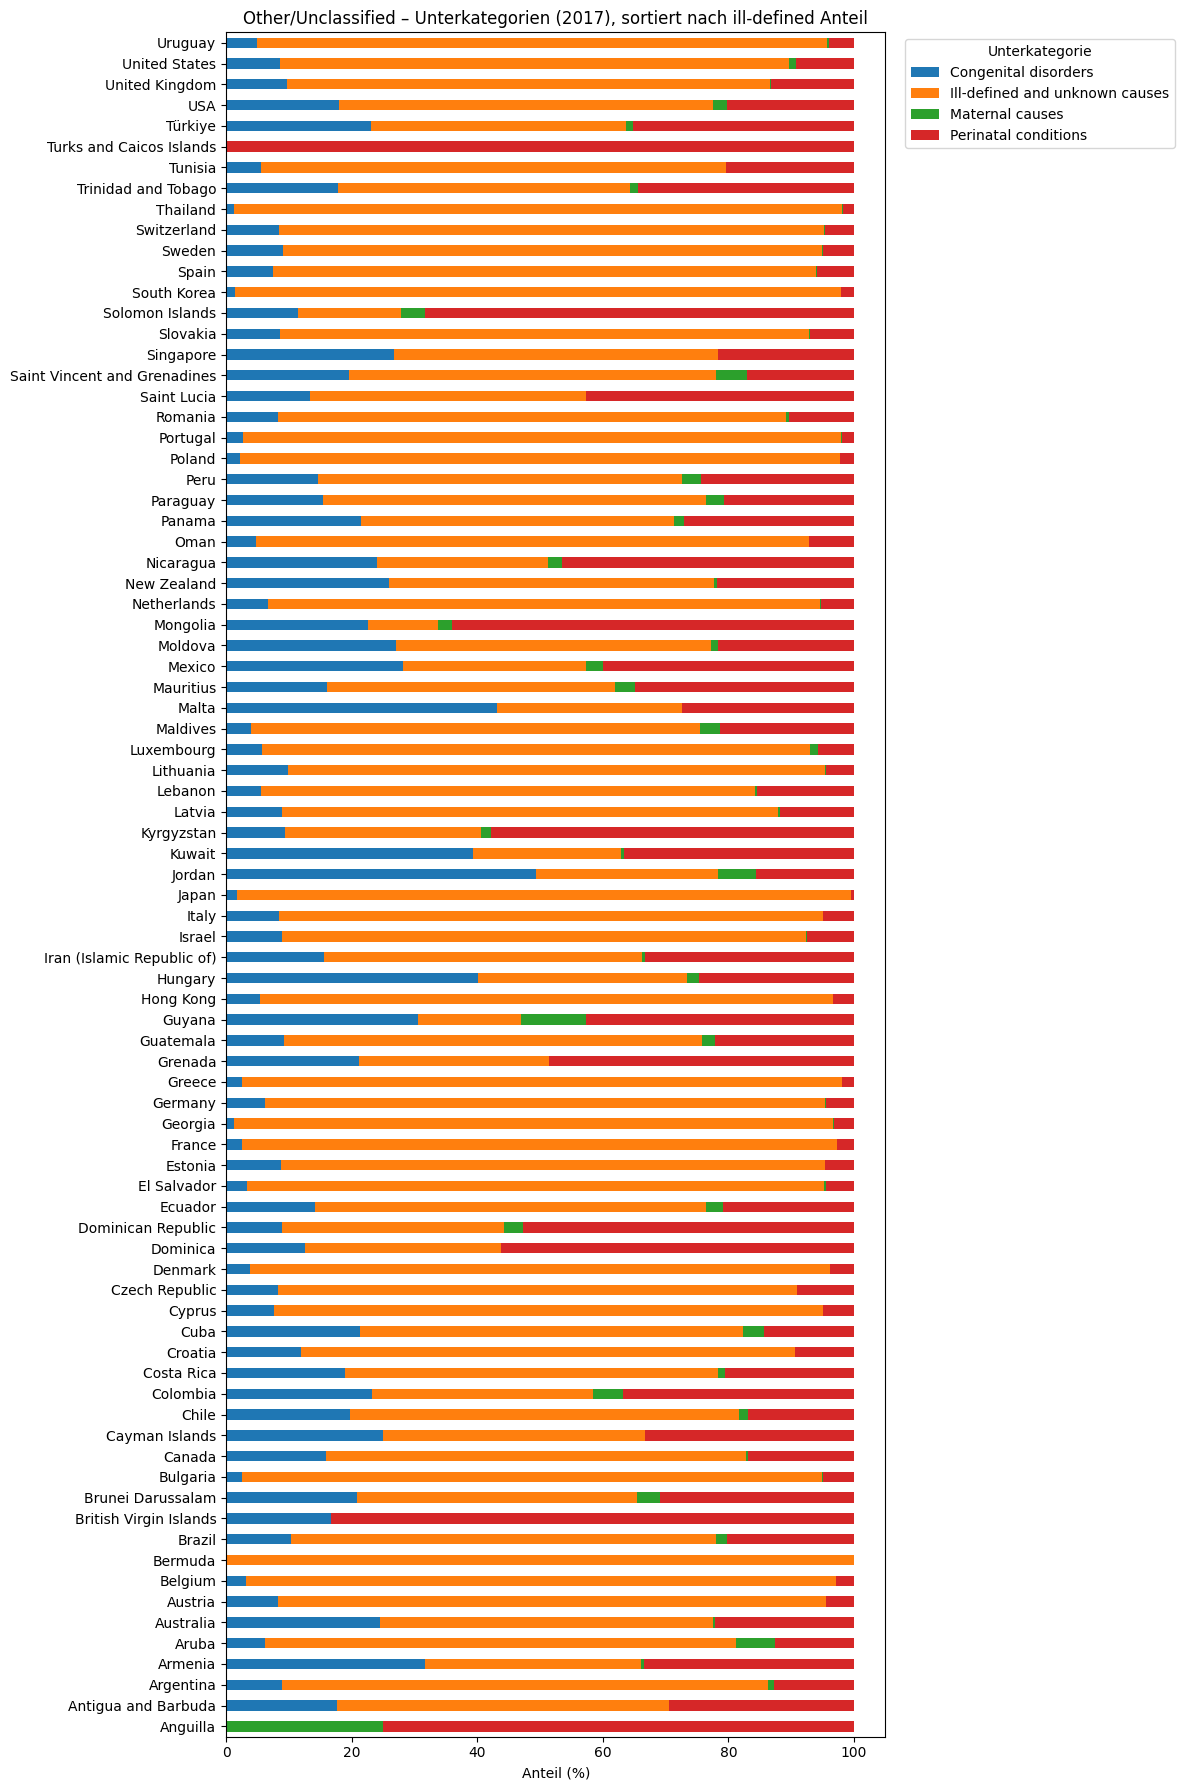

In [19]:
# Wide table for plotting
heat = (other_summary
        .pivot(index="Country_clean", columns="Other_Subcategory", values="Percent")
        .fillna(0))

wide = heat.copy()

ax = wide.plot(kind="barh", stacked=True, figsize=(12, 18))
plt.title("Other/Unclassified – Unterkategorien (2017), sortiert nach ill-defined Anteil")
plt.xlabel("Anteil (%)")
plt.ylabel("")
plt.legend(title="Unterkategorie", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



Die Abbildung zeigt die prozentuale Zusammensetzung der Kategorie „Other / Unclassified“ im Jahr 2017, unterteilt nach ICD-10-Unterkategorien und sortiert nach dem Anteil schlecht definierter und unbekannter Ursachen. In den meisten Ländern wird diese Restkategorie deutlich von ill-defined and unknown causes dominiert, was auf Unterschiede in der Qualität und Detailtiefe der Todesursachenkodierung hinweist.

Einzelne Länder weisen zudem erhöhte Anteile perinataler oder kongenitaler Ursachen innerhalb der „Other“-Kategorie auf, was darauf hindeutet, dass klinisch relevante Todesursachen nicht immer eindeutig den Hauptkategorien zugeordnet werden konnten. Maternal causes spielen hingegen in nahezu allen Ländern nur eine untergeordnete Rolle. 

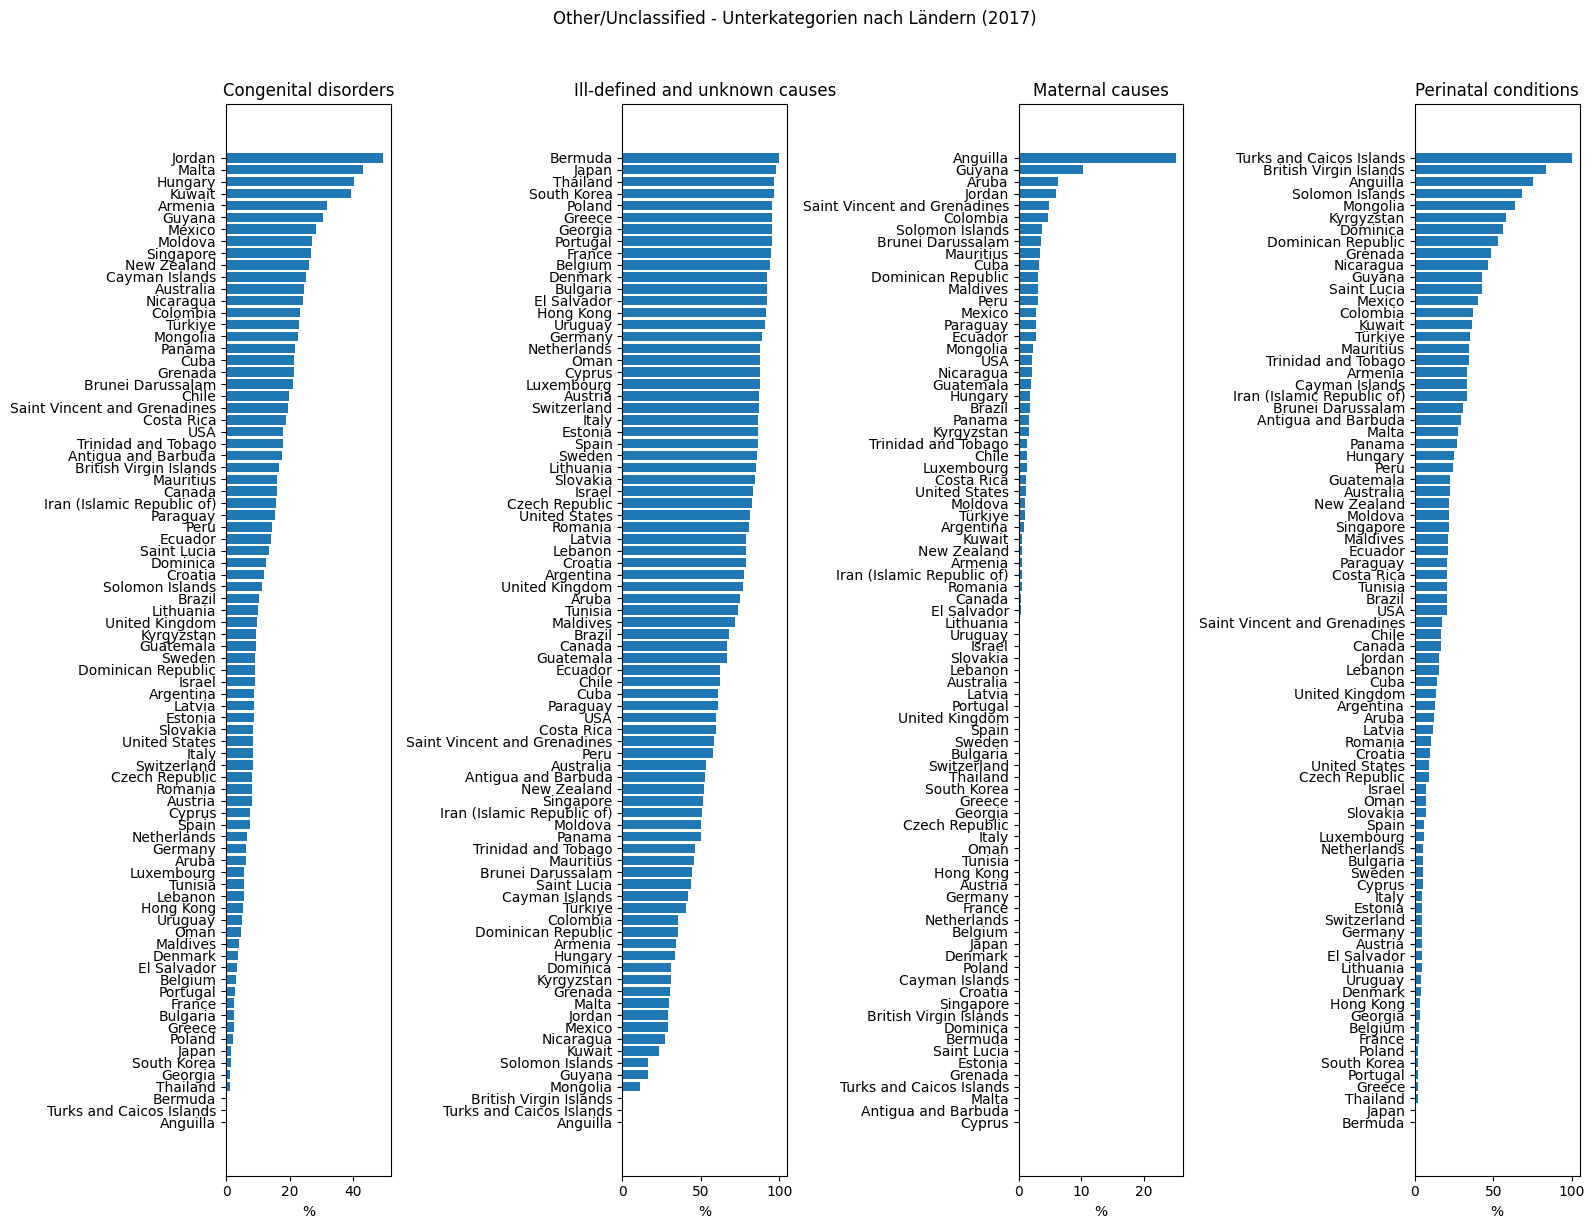

In [20]:
categories = heat.columns.tolist()
fig, axes = plt.subplots(1, len(categories), figsize=(4*len(categories), 12))

for ax, cat in zip(axes, categories):
    tmp = heat[[cat]].sort_values(cat, ascending=True)
    ax.barh(tmp.index, tmp[cat].values)
    ax.set_title(cat)
    ax.set_xlabel("%")

plt.suptitle("Other/Unclassified - Unterkategorien nach Ländern (2017)", y=1.02)
plt.tight_layout()
plt.show()


Zur besseren Lesbarkeit wird die Zusammensetzung von „Other / Unclassified“ zusätzlich als Small-Multiples-Darstellung gezeigt. Für jede Unterkategorie wird separat visualisiert, in welchen Ländern ihr Anteil innerhalb der „Other“-Todesursachen besonders hoch ist. Dadurch lassen sich länderspezifische Ausreisser und Muster pro Unterkategorie klarer erkennen als in einer einzigen gestapelten Gesamtgrafik.

### Häufigste Todesursachen pro Land

In [21]:
pop_raw = pd.read_csv("Data_Files/API_SP.POP.TOTL_DS2_en_csv_v2_34.csv", skiprows=4)
pop_raw.columns = pop_raw.columns.str.strip()

pop_raw = pop_raw[pop_raw["Country Code"].notna()]

pop_2017 = pop_raw[["Country Name", "Country Code", "2017"]].rename(
    columns={"Country Name": "Country_wb", "Country Code": "ISO3", "2017": "Population"}
)
pop_2017["Population"] = pd.to_numeric(pop_2017["Population"], errors="coerce")


In [22]:
wb_map = {
    "USA": "United States",
    "United States of America": "United States",

    "South Korea": "Korea, Rep.",
    "Republic of Korea": "Korea, Rep.",

    "Iran (Islamic Republic of)": "Iran, Islamic Rep.",
    "Iran": "Iran, Islamic Rep.",

    "Türkiye": "Turkiye",
    "Turkey": "Turkiye",

    "Kyrgyzstan": "Kyrgyz Republic",
    "Slovakia": "Slovak Republic",
    "Czech Republic": "Czechia",

    "Hong Kong": "Hong Kong SAR, China",
    "Hong Kong SAR": "Hong Kong SAR, China",

    "Saint Lucia": "St. Lucia",
    "Saint Vincent and Grenadines": "St. Vincent and the Grenadines",

    # territories (only if your deaths data uses these exact labels)
    "Virgin Islands (USA)": "Virgin Islands (U.S.)",
    "Puerto Rico": "Puerto Rico (US)",
}

df_2017_backup["Country_wb"] = df_2017_backup["Country_clean"].replace(wb_map)

df_wb_naming = df_2017_backup[~df_2017_backup["Country_clean"].isin(["Anguilla", "Montserrat"])].copy()



In [23]:
df_wb_naming = df_wb_naming.merge(
    pop_2017[["Country_wb", "Population"]],
    on="Country_wb",
    how="left"
)


In [24]:
missing_after = sorted(df_wb_naming.loc[df_wb_naming["Population"].isna(), "Country_wb"].dropna().unique())
missing_after[:50], len(missing_after)


([], 0)

In [25]:
deaths_countries = set(df_wb_naming["Country_wb"].dropna().unique())
wb_countries = set(pop_2017["Country_wb"].dropna().unique())

sorted(deaths_countries - wb_countries)[:50]


[]

In [26]:
# 1) Are there any duplicate country keys in pop_2017? (should be 0)
pop_2017["Country_wb"].duplicated().sum()

# 2) Does each country in df_wb_naming have exactly one population value?
df_wb_naming.groupby("Country_wb")["Population"].nunique().max()



np.int64(1)

In [27]:
df_wb_naming["Cause_block"] = df_wb_naming["Cause"].astype(str).str[:3]

analysis_df = (
    df_wb_naming
    .groupby(["Country_wb", "Cause_block"], as_index=False)
    .agg(
        Deaths=("Deaths1", "sum"),
        Population=("Population", "first")
    )
)

analysis_df["deaths_per_100k"] = analysis_df["Deaths"] / analysis_df["Population"] * 100000


In [28]:
# 1) Read cause code lookup (ICD block -> name)
codes = pd.read_csv("codes_Files/causes_codes.csv", sep=";", header=None, dtype=str)

cause_lookup = (
    codes[[6, 8]]
    .rename(columns={6: "Cause_block", 8: "Cause_name"})
    .dropna()
    .drop_duplicates(subset=["Cause_block"])
)

# 2) Ensure analysis_df has no old Cause_name before merging (prevents _x/_y)
analysis_df = analysis_df.drop(columns=["Cause_name"], errors="ignore")

# 3) Merge names onto analysis_df
analysis_df = analysis_df.merge(cause_lookup, on="Cause_block", how="left")

# Optional: fill missing names with the code itself (so plots never show NaN labels)
analysis_df["Cause_name"] = analysis_df["Cause_name"].fillna(analysis_df["Cause_block"])

# 4) Top N causes per country
TOP_N = 10
top_causes_per_country = (
    analysis_df.sort_values(["Country_wb", "deaths_per_100k"], ascending=[True, False])
    .groupby("Country_wb")
    .head(TOP_N)
)

print(top_causes_per_country)


                Country_wb Cause_block  Deaths  Population  deaths_per_100k  \
43     Antigua and Barbuda         E14      48     90468.0        53.057435   
62     Antigua and Barbuda         I21      41     90468.0        45.319892   
58     Antigua and Barbuda         I10      29     90468.0        32.055533   
78     Antigua and Barbuda         I64      26     90468.0        28.739444   
59     Antigua and Barbuda         I11      23     90468.0        25.423354   
...                    ...         ...     ...         ...              ...   
51040              Uruguay         J18    1057   3388438.0        31.194314   
50991              Uruguay         I21    1028   3388438.0        30.338463   
51051              Uruguay         J44     980   3388438.0        28.921881   
51016              Uruguay         I64     816   3388438.0        24.081893   
50805              Uruguay         C18     751   3388438.0        22.163605   

                                              Cause

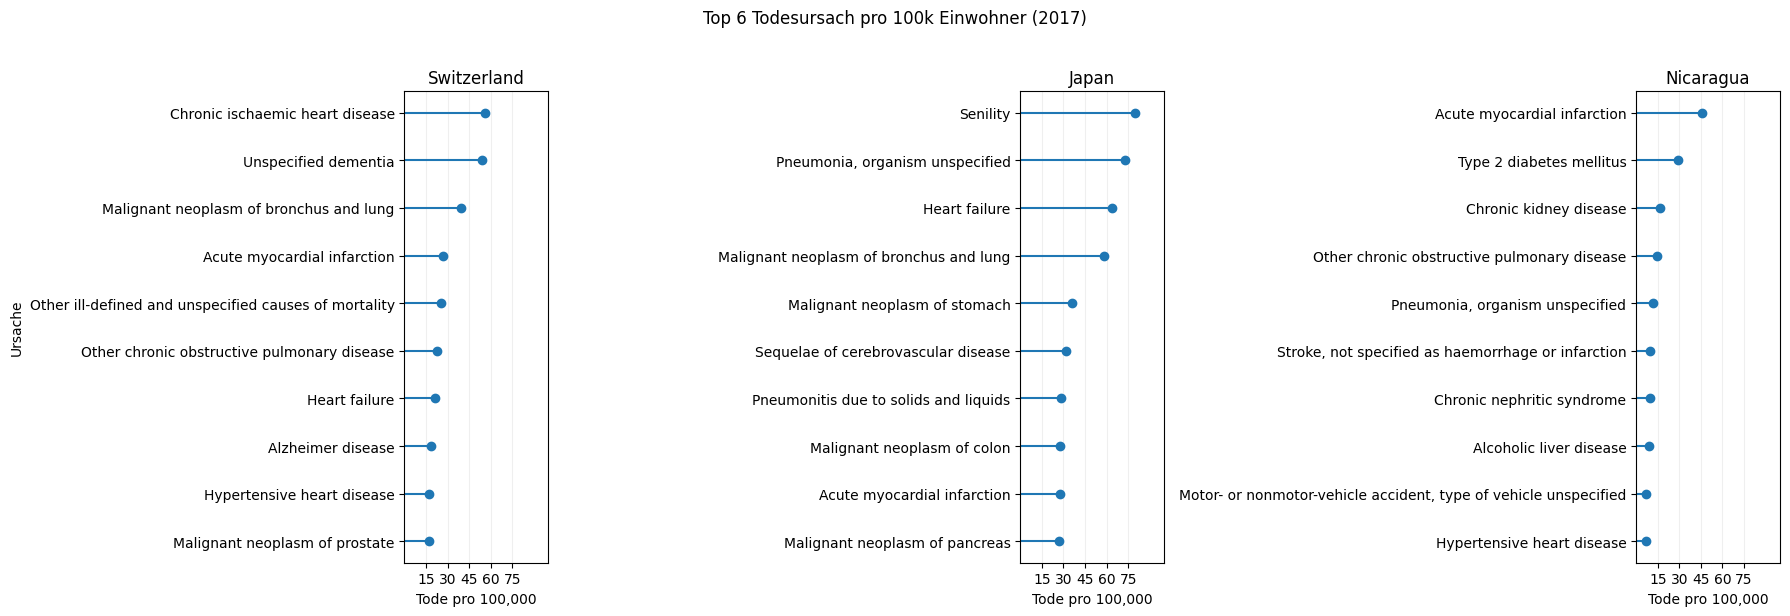

In [36]:
import matplotlib.pyplot as plt

countries = ["Switzerland", "Japan", "Nicaragua"]
fig, axes = plt.subplots(1, len(countries), figsize=(18, 6), sharex=True)

# pick a common max (e.g., 50) OR compute one from data (see below)
xmax = 100
xticks = [15, 30, 45, 60, 75]

for ax, country in zip(axes, countries):
    d = (analysis_df.query("Country_wb == @country")
         .sort_values("deaths_per_100k", ascending=False)
         .head(10)
         .sort_values("deaths_per_100k"))

    ax.hlines(d["Cause_name"], 0, d["deaths_per_100k"])
    ax.plot(d["deaths_per_100k"], d["Cause_name"], marker="o", linestyle="None")
    ax.set_title(country)
    ax.set_xlabel("Tode pro 100'000")
    ax.grid(True, axis="x", alpha=0.2)

    # force same scale
    ax.set_xlim(0, xmax)
    ax.set_xticks(xticks)

axes[0].set_ylabel("Ursache")
plt.suptitle(f"Top {TOP_N} Todesursach pro 100'000 Einwohner (2017)", y=1.02)
plt.tight_layout()
plt.show()


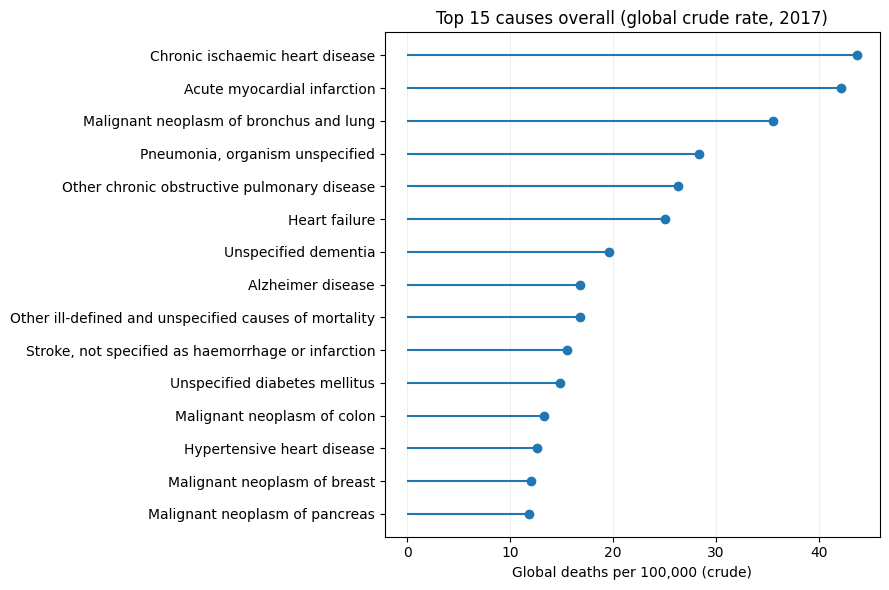

In [37]:
global_cause = (analysis_df.groupby(["Cause_block", "Cause_name"], as_index=False).agg(Deaths=("Deaths", "sum"), Population=("Population", "sum")))

global_cause["global_deaths_per_100k"] = global_cause["Deaths"] / global_cause["Population"] * 100000

global_top = global_cause.sort_values("global_deaths_per_100k", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.hlines(global_top["Cause_name"][::-1], 0, global_top["global_deaths_per_100k"][::-1])
plt.plot(global_top["global_deaths_per_100k"][::-1], global_top["Cause_name"][::-1], "o")
plt.xlabel("Globale Tode pro 100'000 Einwohner (nicht adjustiert)")
plt.title(f"Top {15} Todesursachen insgesamt (nicht adjustiert, 2017)")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


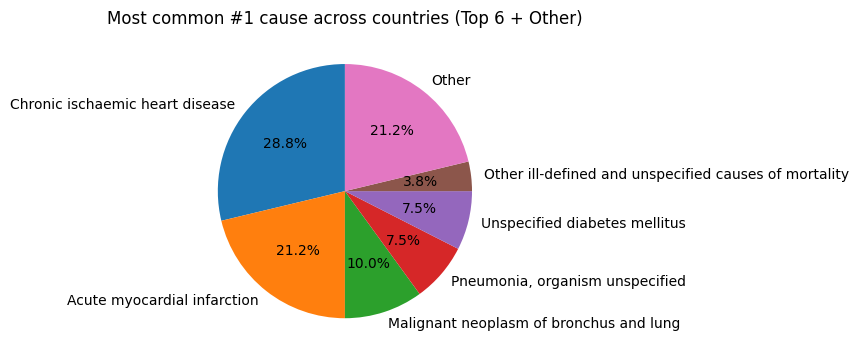

,num_countries
Cause_name,
Chronic ischaemic heart disease,23
Acute myocardial infarction,17
Malignant neoplasm of bronchus and lung,8
"Pneumonia, organism unspecified",6
Unspecified diabetes mellitus,6
Other ill-defined and unspecified causes of mortality,3
Other,17


In [38]:
# 1) Top-1 cause per country
top1 = (analysis_df.sort_values(["Country_wb", "deaths_per_100k"], ascending=[True, False])
        .groupby("Country_wb")
        .head(1))

# 2) Count how often each cause is #1
top1_counts = (top1.groupby("Cause_name")
               .size()
               .sort_values(ascending=False))

# 3) Keep top N, rest goes to "Other"
topN = top1_counts.head(6)
other = top1_counts.iloc[6:].sum()

pie_series = topN.copy()
if other > 0:
    pie_series.loc["Other"] = other
pie_series.to_frame("num_countries")
# 4) Plot pie
plt.figure(figsize=(8, 8))
plt.pie(
    pie_series.values,
    labels=pie_series.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90
)
plt.title(f"Most common #1 cause across countries (Top 6 + Other)")
plt.tight_layout()
plt.show()
pie_series.to_frame("num_countries")